In [ ]:
import torch, os
print("GPU available:", torch.cuda.is_available())


GPU available: True


In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

ROOT = Path("/content/drive/MyDrive/physclip_benchmark")
#ROOT = Path("/content/physclip_benchmark")
DATA_ROOT = ROOT / "data"
CKPT_ROOT = ROOT / "checkpoints"
RESULTS_ROOT = ROOT / "results"

for p in [DATA_ROOT, CKPT_ROOT, RESULTS_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

ROOT, DATA_ROOT


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(PosixPath('/content/drive/MyDrive/physclip_benchmark'),
 PosixPath('/content/drive/MyDrive/physclip_benchmark/data'))

In [ ]:
!pip install -q open_clip_torch torchvision pandas scikit-learn tqdm pyyaml
!pip install -q pathlib


In [ ]:
#This class is your bridge from metadata.csv to actual tensors. You can reuse it for CIFAR-10, SpaceNet, Galaxy10, etc., as long as you prepare a CSV in that same format

import pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

class ImageCSVdset(Dataset):
    def __init__(self, csv_path, root, split="train", img_size=224):
        self.root = Path(root)
        self.df = pd.read_csv(csv_path)
        self.df = self.df[self.df["split"] == split].reset_index(drop=True)
        self.label2id = {lab: i for i, lab in enumerate(sorted(self.df["label"].unique()))}
        self.id2label = {v:k for k,v in self.label2id.items()}
        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.root / row["img_path"]
        img = Image.open(img_path).convert("RGB")
        x = self.transform(img)
        y = self.label2id[row["label"]]
        return x, y


In [ ]:
# ADD CIFAR-10 (faster, sub-sampled)
from torchvision.datasets import CIFAR10
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import numpy as np
import csv

CIFAR_ROOT = DATA_ROOT / "cifar10"
CIFAR_ROOT.mkdir(exist_ok=True, parents=True)

# 1) Download CIFAR
train_ds = CIFAR10(root=CIFAR_ROOT, train=True,  download=True)
test_ds  = CIFAR10(root=CIFAR_ROOT, train=False, download=True)
classes  = train_ds.classes

images_root = CIFAR_ROOT / "images"
images_root.mkdir(exist_ok=True, parents=True)

def save_split(ds, indices, split_name):
    out_dir = images_root / split_name
    out_dir.mkdir(exist_ok=True, parents=True)
    rows = []
    for idx in tqdm(indices, desc=f"CIFAR10 {split_name}"):
        img, label_idx = ds[idx]
        label = classes[label_idx]
        fname = f"{split_name}_{idx:05d}.png"
        abs_path = out_dir / fname
        img.save(abs_path)
        rel_path = abs_path.relative_to(CIFAR_ROOT)
        rows.append({
            "img_path": str(rel_path),
            "label": label,
            "split": split_name,
        })
    return rows

# 2) Create train / val split from CIFAR train set
n_train_total = len(train_ds)   # 50_000
idx_all = np.arange(n_train_total)
rng = np.random.default_rng(42)
rng.shuffle(idx_all)

# use a subset for speed
max_train = 10_000
max_val   = 2_000

train_idx = idx_all[:max_train]
val_idx   = idx_all[max_train:max_train+max_val]

train_rows_small = save_split(train_ds, train_idx, "train")
val_rows         = save_split(train_ds, val_idx,   "val")

# 3) Test split (you can also subsample if you like)
test_idx  = np.arange(len(test_ds))  # 10_000
test_rows = save_split(test_ds, test_idx, "test")

rows = train_rows_small + val_rows + test_rows

# 4) Write metadata.csv
meta_path = CIFAR_ROOT / "metadata.csv"
with open(meta_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["img_path", "label", "split"])
    writer.writeheader()
    writer.writerows(rows)

meta_path


CIFAR10 train:   0%|          | 0/10000 [00:00<?, ?it/s]

CIFAR10 val:   0%|          | 0/2000 [00:00<?, ?it/s]

CIFAR10 test:   0%|          | 0/10000 [00:00<?, ?it/s]

PosixPath('/content/drive/MyDrive/physclip_benchmark/data/cifar10/metadata.csv')

In [ ]:
# # ADD SPACENET DATASET
# SPACENET_ROOT = DATA_ROOT / "spacenet"
# SPACENET_ROOT.mkdir(exist_ok=True, parents=True)

# # If you uploaded a zip file into Drive:
# zip_path = SPACENET_ROOT / "spacenet.zip"
# assert zip_path.exists(), "Upload spacenet.zip to Drive/data/spacenet/ first."

# # Unzip inside Colab (only first time)
# !unzip -q "$zip_path" -d "$SPACENET_ROOT"

# # Now arrange as spacenet/train/<class>/*.png etc.
# # If your zip already has that structure, you can skip re-organizing.
# # We'll build metadata from whatever "train/val/test" folders exist.

# import csv, os

# rows = []
# for split in ["train", "val", "test"]:
#     split_dir = SPACENET_ROOT / split
#     if not split_dir.exists():
#         continue
#     for cls_dir in split_dir.iterdir():
#         if not cls_dir.is_dir():
#             continue
#         label = cls_dir.name
#         for img_name in os.listdir(cls_dir):
#             img_rel = Path(split) / label / img_name
#             rows.append({
#                 "img_path": str(img_rel),
#                 "label": label,
#                 "split": split
#             })

# meta_path = SPACENET_ROOT / "metadata.csv"
# with open(meta_path, "w", newline="") as f:
#     writer = csv.DictWriter(f, fieldnames=["img_path","label","split"])
#     writer.writeheader()
#     writer.writerows(rows)

# meta_path


AssertionError: Upload spacenet.zip to Drive/data/spacenet/ first.

In [ ]:
from pathlib import Path

GZD5_ROOT = DATA_ROOT / "gdz5"
GZD5_ROOT.mkdir(exist_ok=True, parents=True)
GZD5_ROOT


PosixPath('/content/drive/MyDrive/physclip_benchmark/data/gdz5')

In [ ]:
import os
from pathlib import Path

# GZD5_ROOT is defined in a previous cell: DATA_ROOT / "gzd5"

# Download the metadata CSV directly to GZD5_ROOT
# The -c flag will resume if partially downloaded, and -O specifies the output path.
!wget -c "https://zenodo.org/records/4573248/files/gz_decals_volunteers_5.csv?download=1" -O "{GZD5_ROOT}/gz_decals_volunteers_5.csv"

# Define and ensure the raw_data directory exists for the image zips
RAW_DATA_PATH = GZD5_ROOT / "raw_data"
RAW_DATA_PATH.mkdir(parents=True, exist_ok=True)

# Correctly pass the absolute output path for the image zip files
!wget -c "https://zenodo.org/records/4573248/files/gz_decals_dr5_png_part1.zip?download=1" -O "{RAW_DATA_PATH}/gz_decals_dr5_png_part1.zip"
!wget -c "https://zenodo.org/records/4573248/files/gz_decals_dr5_png_part2.zip?download=1" -O "{RAW_DATA_PATH}/gz_decals_dr5_png_part2.zip"
!wget -c "https://zenodo.org/records/4573248/files/gz_decals_dr5_png_part3.zip?download=1" -O "{RAW_DATA_PATH}/gz_decals_dr5_png_part3.zip"
!wget -c "https://zenodo.org/records/4573248/files/gz_decals_dr5_png_part4.zip?download=1" -O "{RAW_DATA_PATH}/gz_decals_dr5_png_part4.zip"

--2025-12-28 09:53:52--  https://zenodo.org/records/4573248/files/gz_decals_volunteers_5.csv?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.185.48.75, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 416 REQUESTED_RANGE_NOT_SATISFIABLE

    The file is already fully retrieved; nothing to do.

--2025-12-28 09:53:53--  https://zenodo.org/records/4573248/files/gz_decals_dr5_png_part1.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.185.48.75, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27789905885 (26G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/physclip_benchmark/data/gdz5/raw_data/gz_decals_dr5_png_part1.zip’

t/drive/MyDrive/phy   0%[                    ]  78.72M   849KB/s    eta 9h 54m ^C
--2025-12-28 09:55:41--  https://zenodo.org/records/

In [ ]:
# import numpy as np
# import pandas as pd
# from pathlib import Path
# from sklearn.model_selection import train_test_split

# GZD5_ROOT = DATA_ROOT / "gzd5"

# # 1) Load catalogue
# cat = pd.read_csv(GZD5_ROOT / "gz_decals_volunteers_5.csv")

# print("Raw catalogue rows:", len(cat))

# # 2) Build binary label: smooth vs disk, using high-confidence fractions
# smooth_f = cat["smooth-or-featured_smooth_fraction"]
# disk_f   = cat["smooth-or-featured_featured-or-disk_fraction"]

# # high-confidence: one of them ≥ 0.7 and the other ≤ 0.3
# mask = ((smooth_f >= 0.7) & (disk_f <= 0.3)) | ((disk_f >= 0.7) & (smooth_f <= 0.3))
# cat = cat[mask].copy()
# smooth_f = smooth_f[mask]
# disk_f   = disk_f[mask]

# cat["label"] = np.where(disk_f > smooth_f, "disk", "smooth")
# print("After confidence filter, rows:", len(cat))
# print(cat["label"].value_counts())

# # 3) Turn png_loc into an actual image path

# def build_img_path(png_loc: str) -> Path:
#     """
#     png_loc in the CSV is usually something like 'images/1000/123456.png'
#     or '/some/long/path/images/1000/123456.png'.

#     We just need the last two components '1000/123456.png'
#     and then prepend GZD5_ROOT / 'images_raw'.
#     """
#     p = Path(png_loc)
#     # Keep the last two pieces (folder + file). If your png_loc looks
#     # different, you can change -2 to -3 etc.
#     p = Path(*p.parts[-2:])
#     return GZD5_ROOT / "images_raw" / p

# cat["img_path"] = cat["png_loc"].apply(build_img_path)

# exists = cat["img_path"].apply(lambda p: p.is_file())
# print("Rows with existing PNG:", int(exists.sum()))

# cat = cat[exists].reset_index(drop=True)
# print("After matching images, rows:", len(cat))

# # Sanity check – make sure we really have something left
# display(cat[["png_loc", "img_path", "label"]].head())

# # 4) Train/val/test split (stratified by label)
# train_df, temp_df = train_test_split(
#     cat, test_size=0.15, random_state=42, stratify=cat["label"]
# )
# val_df, test_df = train_test_split(
#     temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"]
# )

# train_df["split"] = "train"
# val_df["split"]   = "val"
# test_df["split"]  = "test"

# meta = pd.concat([train_df, val_df, test_df], ignore_index=True)
# meta_simple = meta[["img_path", "label", "split"]]

# meta_path = GZD5_ROOT / "metadata.csv"
# meta_simple.to_csv(meta_path, index=False)

# print("GZD5 metadata written to:", meta_path)
# print(meta_simple["label"].value_counts(), "\n")


In [ ]:
GZD5_ROOT = DATA_ROOT / "gzd5"
%cd $GZD5_ROOT
!pwd
!ls


In [ ]:
# ADD CLIP BASELINE
import open_clip
import torchvision.transforms as T
from PIL import Image
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai"
)
clip_model.to(device).eval()

@torch.no_grad()
def encode_clip_image(path, img_size=224):
    img = Image.open(path).convert("RGB")
    img = clip_preprocess(img).unsqueeze(0).to(device)  # clip_preprocess already resizes etc.
    feats = clip_model.encode_image(img)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.squeeze(0).cpu()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [ ]:
# Generic “extract embeddings + linear probe classifier” function
from tqdm.auto import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
)

def extract_embeddings(meta_csv, root, encode_fn):
    df = pd.read_csv(meta_csv)
    root = Path(root)

    X_list, y_list, splits = [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Embed {meta_csv.name}"):
        path = root / row["img_path"]
        z = encode_fn(path)          # 1D tensor on CPU
        X_list.append(z.numpy())
        y_list.append(row["label"])
        splits.append(row["split"])

    X = np.stack(X_list)
    y = np.array(y_list)
    splits = np.array(splits)
    return X, y, splits

def eval_linear_probe(
    dataset_name,
    root,
    encode_fn,
    metric_type="balanced",
    few_shot_per_class=None,   # None = full shot
):
    root = Path(root)
    meta_csv = root / "metadata.csv"
    X, y, splits = extract_embeddings(meta_csv, root, encode_fn)

    train_mask = (splits == "train")
    val_mask   = (splits == "val")
    test_mask  = (splits == "test")

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # Optional few-shot: take at most K examples per class
    if few_shot_per_class is not None:
        rng = np.random.default_rng(0)
        X_small, y_small = [], []
        for lab in np.unique(y_train):
            idx = np.where(y_train == lab)[0]
            rng.shuffle(idx)
            idx = idx[:few_shot_per_class]
            X_small.append(X_train[idx])
            y_small.append(y_train[idx])
        X_train = np.concatenate(X_small, axis=0)
        y_train = np.concatenate(y_small, axis=0)
        print(f"{dataset_name} few-shot: {few_shot_per_class} per class → {len(y_train)} train examples")

    clf = LogisticRegression(max_iter=1000, multi_class="multinomial")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    if metric_type == "acc":
        score = accuracy_score(y_test, y_pred)
    elif metric_type == "balanced":
        score = balanced_accuracy_score(y_test, y_pred)
    elif metric_type == "f1":
        score = f1_score(y_test, y_pred, average="macro")
    else:
        raise ValueError("unknown metric_type")

    print(f"{dataset_name}: {metric_type} = {score:.4f} (test n={len(y_test)})")
    return score


In [ ]:
# Run CLIP on all three image-classification datasets
# CIFAR-10: general dataset
eval_linear_probe("CIFAR-10", DATA_ROOT / "cifar10", encode_clip_image, metric_type="acc")

# SpaceNet: 8-way astro images
# val_linear_probe("SpaceNet", DATA_ROOT / "spacenet", encode_clip_image, metric_type="acc")

# GZD-5: imbalanced morphology -> balanced accuracy + F1
# print("GZD-5:")
# acc_bal = eval_linear_probe("GZD-5_balanced", DATA_ROOT / "gzd5", encode_clip_image, metric_type="balanced")
# f1      = eval_linear_probe("GZD-5_F1", DATA_ROOT / "gzd5", encode_clip_image, metric_type="f1")


In [ ]:
#Run retrieval with CLIP
PHYS_ARXIV_ROOT = DATA_ROOT / "physclip_arxiv"   # where your pairs live

eval_retrieval_physclip_arxiv(PHYS_ARXIV_ROOT, encode_clip_image, encode_clip_texts)


In [ ]:
# 1) Check environment
import sys, torch
print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA:", torch.version.cuda, "GPU:", torch.cuda.is_available())

# 2) Basic deps for your benchmark
!pip -q install -U pip
!pip -q install open-clip-torch scikit-learn pandas tqdm pyyaml

# 3) Minimal deps AstroCLIP needs for inference/embeddings
!pip -q install lightning torchmetrics omegaconf fvcore iopath astropy huggingface_hub jaxtyping

# 4) Install DINOv2 + AstroCLIP WITHOUT pulling their pinned torch/torchvision requirements
#    (critical on Python 3.12)
!pip -q install --no-deps git+https://github.com/facebookresearch/dinov2.git@2302b6bf46953431b969155307b9bed152754069
!pip -q install --no-deps git+https://github.com/PolymathicAI/AstroCLIP.git


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch: 2.9.0+cu126
CUDA: 12.6 GPU: True
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dinov2 0.0.1 requires submitit, which is not installed.
dinov2 0.0.1 requires xformers==0.0.18, which is not installed.
dinov2 0.0.1 requires torch==2.0.0, but you have torch 2.9.0+cu126 which is incompatible.
dinov2 0.0.1 requires torchmetrics==0.10.3, but you have torchmetrics 1.8.2 which is incompatible.
dinov2 0.0.1 requires torchvision==0.15.0, but you have torchvision 0.24.0+cu126 which is incompatible.
  Installing build dependencies ... done
  

In [ ]:
# !pip install -q open-clip-torch scikit-learn

# # AstroCLIP and its deps – this is heavy and may take several minutes
# !apt install -y python3-dev libcairo2-dev pkg-config
# !pip install -q --upgrade pip
# !pip install -q "lightning[extra]==2.3.3" "boto3==1.28.17"
# !pip install -q --upgrade pycairo datasets pyarrow
# !pip install -q --extra-index-url https://pypi.nvidia.com cuml-cu11
# !pip install -q --extra-index-url https://download.pytorch.org/whl/cu117 "torch==2.0.0+cu117"
# !pip install -q "torchvision==0.15.0" "torchmetrics==0.10.3" dotenv "numpy==1.26.4" omegaconf fvcore iopath
# !pip install -q --no-deps git+https://github.com/facebookresearch/dinov2.git@2302b6bf46953431b969155307b9bed152754069

# !pip install -q astropy huggingface_hub jaxtyping wandb networkx pyvis
# !pip install -U git+https://github.com/facebookresearch/dinov2.git
# !pip install -U git+https://github.com/PolymathicAI/AstroCLIP.git

# # Download AstroCLIP checkpoint
# !wget -q -O astroclip.ckpt \
#   "https://huggingface.co/polymathic-ai/astroclip/resolve/main/astroclip.ckpt?download=true"


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libcairo2-dev is already the newest version (1.16.0-5ubuntu2).
pkg-config is already the newest version (0.29.2-1ubuntu3).
python3-dev is already the newest version (3.10.6-1~22.04.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcudf-cu11 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cudf-cu11 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cudf-cu12 25.10.0 requires cuda-python<13.0a0,>=

In [ ]:
import astroclip
from astroclip.models import AstroClipModel
print("AstroCLIP import OK")


/usr/local/lib/python3.12/dist-packages/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/usr/local/lib/python3.12/dist-packages/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/usr/local/lib/python3.12/dist-packages/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


AstroCLIP import OK


In [ ]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from tqdm.auto import tqdm
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [ ]:
#Load CIFAR-10 once without transform
root = "./data"

base_train = datasets.CIFAR10(root=root, train=True, download=True, transform=None)
base_test  = datasets.CIFAR10(root=root, train=False, download=True, transform=None)

num_train = 45000
num_val   = len(base_train) - num_train
train_base, val_base = random_split(base_train, [num_train, num_val])

class_names = base_train.classes
print("Classes:", class_names)


In [ ]:
#CLIP encoder + CLIP-style CIFAR loaders
import open_clip

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
clip_model = clip_model.to(device).eval()



In [ ]:
from torch.utils.data import Dataset

class TransformWrapper(Dataset):
    def __init__(self, base_dataset, transform):
        self.base = base_dataset
        self.transform = transform
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        img, label = self.base[idx]
        img = self.transform(img)
        return img, label

train_clip = TransformWrapper(train_base, clip_preprocess)
test_clip  = TransformWrapper(base_test,  clip_preprocess)

train_clip_loader = DataLoader(train_clip, batch_size=128, shuffle=True,  num_workers=2)
test_clip_loader  = DataLoader(test_clip,  batch_size=128, shuffle=False, num_workers=2)


In [ ]:
def get_clip_features(dataloader):
    xs, ys = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(dataloader, desc="CLIP feats"):
            imgs = imgs.to(device)
            feats = clip_model.encode_image(imgs)
            feats = feats / feats.norm(dim=-1, keepdim=True)
            xs.append(feats.cpu())
            ys.append(labels)
    X = torch.cat(xs).numpy()
    y = torch.cat(ys).numpy()
    return X, y


In [ ]:
# 1. Remove the broken pyarrow
!pip uninstall -y pyarrow

# 2. Install a fresh recent version (works with HF datasets & Colab + Python 3.12)
!pip install -q "pyarrow==19.0.1"


import pyarrow as pa
print("PyArrow version:", pa.__version__)




In [ ]:
import os
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"  # must be set BEFORE importing torch

import torch
from astroclip.models import AstroClipModel

device = "cuda" if torch.cuda.is_available() else "cpu"
astro_model = AstroClipModel.load_from_checkpoint(
    checkpoint_path="astroclip.ckpt",
    map_location=device,
)
astro_model = astro_model.to(device).eval()


In [ ]:
astro_transform = transforms.Compose([
    transforms.Resize((144, 144)),
    transforms.ToTensor(),
])

train_astro = TransformWrapper(train_base, astro_transform)
test_astro  = TransformWrapper(base_test,  astro_transform)

train_astro_loader = DataLoader(train_astro, batch_size=128, shuffle=True,  num_workers=2)
test_astro_loader  = DataLoader(test_astro,  batch_size=128, shuffle=False, num_workers=2)


In [ ]:
import torch
from tqdm import tqdm
import numpy as np

astro_model.eval()          # make sure we are in eval mode
astro_model.to(device)      # ensure model is on the same device as CLIP


def get_astro_features(dataloader):
    X_list, y_list = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader, desc="AstroCLIP feats"):
            imgs = imgs.to(device)

            # ---- 1. Forward pass through AstroCLIP ----
            out = astro_model(imgs, input_type="image")

            # ---- 2. Make this robust to different return types ----
            if isinstance(out, dict):
                # Official AstroCLIP returns a dict
                # Try common keys; fall back to "first item"
                if "image_embedding" in out:
                    feats = out["image_embedding"]
                elif "embedding" in out:
                    feats = out["embedding"]
                else:
                    # just take the first value in the dict
                    feats = next(iter(out.values()))
            elif isinstance(out, (list, tuple)):
                # Some Lightning modules return (embedding, ...)
                feats = out[0]
            else:
                # Already a tensor (B, D)
                feats = out

            # ---- 3. Normalise embeddings (like CLIP) ----
            feats = feats.float()
            feats = feats / feats.norm(dim=-1, keepdim=True)

            X_list.append(feats.cpu())
            y_list.append(labels)

    X = torch.cat(X_list, dim=0).numpy()
    y = torch.cat(y_list, dim=0).numpy()
    return X, y


In [ ]:
#Train linear probes and compute accuracy on CIFAR-10

# Extract features
X_train_clip, y_train = get_clip_features(train_clip_loader)
X_test_clip,  y_test  = get_clip_features(test_clip_loader)

X_train_astro, _ = get_astro_features(train_astro_loader)
X_test_astro,  _ = get_astro_features(test_astro_loader)

# Train & evaluate linear probes (your existing code)
clf_clip = LogisticRegression(max_iter=1000, multi_class="multinomial")
clf_clip.fit(X_train_clip, y_train)
acc_clip = accuracy_score(y_test, clf_clip.predict(X_test_clip))
print(f"CLIP = linear probe accuracy on CIFAR-10: {acc_clip:.3f}")

clf_astro = LogisticRegression(max_iter=1000, multi_class="multinomial")
clf_astro.fit(X_train_astro, y_train)
acc_astro = accuracy_score(y_test, clf_astro.predict(X_test_astro))
print(f"AstroCLIP = linear probe accuracy on CIFAR-10: {acc_astro:.3f}")




In [ ]:
#Simple visualization of the results
models = ["CLIP", "AstroCLIP"]
accs   = [acc_clip, acc_astro]

plt.figure(figsize=(4,4))
plt.bar(models, accs)
plt.ylabel("Top-1 accuracy on CIFAR-10")
plt.ylim(0, 1.0)
for i, a in enumerate(accs):
    plt.text(i, a + 0.01, f"{a:.3f}", ha="center")
plt.show()


In [ ]:
# #For zero-shot
# @torch.no_grad()
# def encode_clip_text(prompts):
#     tokens = open_clip.tokenize(prompts).to(device)
#     feats = clip_model.encode_text(tokens)
#     feats = feats / feats.norm(dim=-1, keepdim=True)
#     return feats.cpu()

# @torch.no_grad()
# def encode_astro_text(prompts):
#     # You may need to tokenize with their tokenizer; placeholder:
#     # tokens = astro_tokenizer(prompts).to(device)
#     # feats = astro_model.encode_text(tokens)
#     # Here I assume astro_model has encode_text(prompts) for simplicity:
#     feats = astro_model.encode_text(prompts)  # <- adjust to real API
#     feats = feats / feats.norm(dim=-1, keepdim=True)
#     return feats.cpu()

# # @torch.no_grad()
# # def encode_phys_text(prompts):
# #     # tokens = phys_tokenizer(prompts).to(device)
# #     # feats = phys_model.encode_text(tokens)
# #     feats = phys_model.encode_text(prompts)  # adapt to your API
# #     feats = feats / feats.norm(dim=-1, keepdim=True)
# #     return feats.cpu()


In [ ]:
# def zero_shot_eval(
#     dataset_name,
#     root,
#     label_names,
#     encode_image_fn,
#     encode_text_fn,
#     prompt_template="an image of a {} galaxy",
# ):
#     root = Path(root)
#     df = pd.read_csv(root / "metadata.csv")
#     df = df[df["split"] == "test"].reset_index(drop=True)

#     # Build prompts
#     class_names = sorted(label_names)
#     prompts = [prompt_template.format(c) for c in class_names]
#     text_emb = encode_text_fn(prompts).numpy()
#     text_emb /= np.linalg.norm(text_emb, axis=-1, keepdims=True)  # (C, D)

#     y_true, y_pred = [], []

#     for _, row in tqdm(df.iterrows(), total=len(df), desc=f"{dataset_name} zero-shot"):
#         path = root / row["img_path"]
#         img_emb = encode_image_fn(path).numpy()
#         img_emb /= np.linalg.norm(img_emb)

#         sims = img_emb @ text_emb.T      # (C,)
#         pred_idx = np.argmax(sims)
#         y_true.append(row["label"])
#         y_pred.append(class_names[pred_idx])

#     bal_acc = balanced_accuracy_score(y_true, y_pred)
#     f1 = f1_score(y_true, y_pred, average="macro")
#     print(f"{dataset_name} zero-shot: bal_acc={bal_acc:.4f}, F1={f1:.4f}")

#     return bal_acc, f1


In [ ]:
# gzd5_labels = ["smooth", "disk"]

# zs_clip  = zero_shot_eval(
#     "GZD5-CLIP",
#     GZD5_ROOT,
#     gzd5_labels,
#     encode_clip_image,
#     encode_clip_text,
#     prompt_template="an image of a {} galaxy"
# )

# # Only run these if you really have text encoders:
# zs_astro = zero_shot_eval(
#     "GZD5-AstroCLIP",
#     GZD5_ROOT,
#     gzd5_labels,
#     encode_astro_image,
#     encode_astro_text,
#     prompt_template="an image of a {} galaxy"
# )

# zs_phys = zero_shot_eval(
#     "GZD5-PhysCLIP",
#     GZD5_ROOT,
#     gzd5_labels,
#     encode_phys_image,
#     encode_phys_text,
#     prompt_template="an image of a {} galaxy"
# )


In [ ]:
# #Extract embeddings once per model
# def extract_embeddings(root, encode_image_fn):
#     root = Path(root)
#     df = pd.read_csv(root / "metadata.csv")

#     X_list, y_list, split_list = [], [], []

#     for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Embed {root.name}"):
#         path = root / row["img_path"]
#         z = encode_image_fn(path)
#         X_list.append(z.numpy())
#         y_list.append(row["label"])
#         split_list.append(row["split"])

#     X = np.stack(X_list)
#     y = np.array(y_list)
#     splits = np.array(split_list)
#     return X, y, splits


In [ ]:
# def linear_probe_eval(
#     dataset_name,
#     X,
#     y,
#     splits,
#     few_shot_per_class=None,
# ):
#     # Split train/test
#     train_mask = (splits == "train")
#     test_mask  = (splits == "test")

#     X_train, y_train = X[train_mask], y[train_mask]
#     X_test,  y_test  = X[test_mask],  y[test_mask]

#     # Optional few-shot: keep K per class
#     if few_shot_per_class is not None:
#         rng = np.random.default_rng(0)
#         X_small, y_small = [], []
#         for lab in np.unique(y_train):
#             idx = np.where(y_train == lab)[0]
#             rng.shuffle(idx)
#             idx = idx[:few_shot_per_class]
#             X_small.append(X_train[idx])
#             y_small.append(y_train[idx])
#         X_train = np.concatenate(X_small, axis=0)
#         y_train = np.concatenate(y_small, axis=0)
#         print(f"{dataset_name}: {few_shot_per_class} examples/class → {len(y_train)} total")

#     clf = LogisticRegression(max_iter=1000, multi_class="multinomial")
#     clf.fit(X_train, y_train)
#     y_pred = clf.predict(X_test)

#     bal_acc = balanced_accuracy_score(y_test, y_pred)
#     f1 = f1_score(y_test, y_pred, average="macro")
#     print(f"{dataset_name}: bal_acc={bal_acc:.4f}, F1={f1:.4f}")
#     return bal_acc, f1


In [ ]:
# # Extract embeddings once per model
# X_clip,  y_gzd5, splits_gzd5 = extract_embeddings(GZD5_ROOT, encode_clip_image)
# X_astro, _,      _           = extract_embeddings(GZD5_ROOT, encode_astro_image)
# X_phys,  _,      _           = extract_embeddings(GZD5_ROOT, encode_phys_image)

# results = []  # we’ll collect everything here

# # --- Full-shot ---
# bal, f1 = linear_probe_eval("GZD5-CLIP full", X_clip, y_gzd5, splits_gzd5)
# results.append({"dataset": "GZD5", "regime": "full-shot", "model": "CLIP",
#                 "bal_acc": bal, "f1": f1})

# bal, f1 = linear_probe_eval("GZD5-AstroCLIP full", X_astro, y_gzd5, splits_gzd5)
# results.append({"dataset": "GZD5", "regime": "full-shot", "model": "AstroCLIP",
#                 "bal_acc": bal, "f1": f1})

# bal, f1 = linear_probe_eval("GZD5-PhysCLIP full", X_phys, y_gzd5, splits_gzd5)
# results.append({"dataset": "GZD5", "regime": "full-shot", "model": "PhysCLIP",
#                 "bal_acc": bal, "f1": f1})

# # --- Few-shot (e.g. 20 per class) ---
# K = 20
# bal, f1 = linear_probe_eval("GZD5-CLIP few", X_clip, y_gzd5, splits_gzd5, few_shot_per_class=K)
# results.append({"dataset": "GZD5", "regime": f"{K}-shot", "model": "CLIP",
#                 "bal_acc": bal, "f1": f1})

# bal, f1 = linear_probe_eval("GZD5-AstroCLIP few", X_astro, y_gzd5, splits_gzd5, few_shot_per_class=K)
# results.append({"dataset": "GZD5", "regime": f"{K}-shot", "model": "AstroCLIP",
#                 "bal_acc": bal, "f1": f1})

# bal, f1 = linear_probe_eval("GZD5-PhysCLIP few", X_phys, y_gzd5, splits_gzd5, few_shot_per_class=K)
# results.append({"dataset": "GZD5", "regime": f"{K}-shot", "model": "PhysCLIP",
#                 "bal_acc": bal, "f1": f1})

# # --- Zero-shot results we computed earlier ---
# results.append({"dataset": "GZD5", "regime": "zero-shot", "model": "CLIP",
#                 "bal_acc": zs_clip[0], "f1": zs_clip[1]})
# results.append({"dataset": "GZD5", "regime": "zero-shot", "model": "AstroCLIP",
#                 "bal_acc": zs_astro[0], "f1": zs_astro[1]})
# results.append({"dataset": "GZD5", "regime": "zero-shot", "model": "PhysCLIP",
#                 "bal_acc": zs_phys[0], "f1": zs_phys[1]})

# results_df = pd.DataFrame(results)
# results_df


In [ ]:
# #visualize the results
# def plot_bars(results_df, dataset="GZD5"):
#     df = results_df[results_df["dataset"] == dataset].copy()
#     models = ["CLIP", "AstroCLIP", "PhysCLIP"]
#     regimes = ["zero-shot", "20-shot", "full-shot"]  # adjust if you used different K

#     for metric in ["bal_acc", "f1"]:
#         plt.figure(figsize=(8, 4))
#         x = np.arange(len(models))
#         width = 0.25

#         for i, reg in enumerate(regimes):
#             sub = df[df["regime"] == reg].set_index("model").reindex(models)
#             plt.bar(x + i*width, sub[metric], width=width, label=reg)

#         plt.xticks(x + width, models)
#         plt.ylabel(metric)
#         plt.title(f"{dataset} {metric}")
#         plt.ylim(0, 1)
#         plt.legend()
#         plt.show()

# plot_bars(results_df, dataset="GZD5")


In [ ]:
# def plot_lines(results_df, dataset="GZD5"):
#     df = results_df[results_df["dataset"] == dataset].copy()
#     models = ["CLIP", "AstroCLIP", "PhysCLIP"]
#     regimes = ["zero-shot", "20-shot", "full-shot"]
#     x = np.arange(len(regimes))

#     for metric in ["bal_acc", "f1"]:
#         plt.figure(figsize=(8, 4))
#         for model in models:
#             sub = df[df["model"] == model].set_index("regime").reindex(regimes)
#             plt.plot(x, sub[metric], marker="o", label=model)
#         plt.xticks(x, regimes)
#         plt.ylabel(metric)
#         plt.title(f"{dataset} {metric}")
#         plt.ylim(0, 1)
#         plt.legend()
#         plt.grid(alpha=0.3)
#         plt.show()

# plot_lines(results_df, dataset="GZD5")


In [ ]:
# Install Kaggle CLI once
!pip install -q kaggle


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"trnnamnguytanh","key":"4cdd52bc328f6d9f76703e464d8f930d"}'}

In [ ]:
!pip -q install --upgrade kaggle

!mkdir -p /root/.config/kaggle
!cp kaggle.json /root/.config/kaggle/kaggle.json
!chmod 600 /root/.config/kaggle/kaggle.json

!ls -l /root/.config/kaggle/



cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.config/kaggle/kaggle.json': No such file or directory
total 0


In [ ]:
%cd $SPACENET_ROOT
!kaggle datasets download -d razaimam45/spacenet-an-optimally-distributed-astronomy-data -p $SPACENET_ROOT


/content/drive/MyDrive/physclip_benchmark/data/spacenet
Dataset URL: https://www.kaggle.com/datasets/razaimam45/spacenet-an-optimally-distributed-astronomy-data
License(s): CC-BY-SA-4.0
100% 52.7G/52.7G [24:25<00:00, 30.9MB/s]
100% 52.7G/52.7G [24:25<00:00, 38.6MB/s]


In [ ]:
from pathlib import Path

SPACENET_ROOT = DATA_ROOT / "spacenet"
SPACENET_ROOT.mkdir(parents=True, exist_ok=True)

SPACENET_ROOT


PosixPath('/content/drive/MyDrive/physclip_benchmark/data/spacenet')

In [ ]:
%cd /content/drive/MyDrive/physclip_benchmark/data/spacenet
!ls -lh

!mkdir -p data_raw
!unzip -q "*.zip" -d data_raw

!ls -lh data_raw | head


/content/drive/MyDrive/physclip_benchmark/data/spacenet
total 53G
-rw------- 1 root root 53G Aug 30  2024 spacenet-an-optimally-distributed-astronomy-data.zip
data_raw/SpaceNet.FLARE.imam_alam/star/star_page_3_image_16_aug3_SwinIR_large.png:  write error (disk full?).  Continue? (y/n/^C) y
data_raw/SpaceNet.FLARE.imam_alam/star/star_page_3_image_16_aug3_SwinIR_large.png  bad CRC c3917754  (should be a5b8eac6)

1 archive had fatal errors.
total 4.0K
drwx------ 10 root root 4.0K Dec 21 08:43 SpaceNet.FLARE.imam_alam


In [ ]:
%cd /content/drive/MyDrive/physclip_benchmark/data/spacenet
!unzip -n spacenet-an-optimally-distributed-astronomy-data.zip -d data_raw


/content/drive/MyDrive/physclip_benchmark/data/spacenet
Archive:  spacenet-an-optimally-distributed-astronomy-data.zip


In [ ]:

# (3) SpaceNet paths
from pathlib import Path
SPACENET_ROOT = DATA_ROOT / "spacenet"
RAW_DIR = SPACENET_ROOT / "data_raw"   # where you unzipped

from pathlib import Path

# put cache on Drive so it survives disconnects
CACHE_ROOT = Path("/content/drive/MyDrive/physclip_benchmark/cache")
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

print("CACHE_ROOT =", CACHE_ROOT)

SPACENET_ROOT.mkdir(parents=True, exist_ok=True)

print("SPACENET_ROOT:", SPACENET_ROOT)
print("RAW_DIR exists?", RAW_DIR.exists(), RAW_DIR)


CACHE_ROOT = /content/drive/MyDrive/physclip_benchmark/cache
SPACENET_ROOT: /content/drive/MyDrive/physclip_benchmark/data/spacenet
RAW_DIR exists? True /content/drive/MyDrive/physclip_benchmark/data/spacenet/data_raw


In [ ]:

# (4) Build SpaceNet CSV (run once). If you already have it, this will just reuse it.
import random
import pandas as pd
from sklearn.model_selection import train_test_split

CLASSES = ["Planet","Asteroid","Nebula","Comet","Star","Black Hole","Galaxy","Constellation"]
# map folder token -> canonical label
CLASS_MAP = {
    "planet":"Planet",
    "asteroid":"Asteroid",
    "nebula":"Nebula",
    "comet":"Comet",
    "star":"Star",
    "black_hole":"Black Hole",
    "blackhole":"Black Hole",
    "galaxy":"Galaxy",
    "constellation":"Constellation",
}

def infer_label_from_path(p: Path):
    parts = [x.lower() for x in p.parts]
    for token, canon in CLASS_MAP.items():
        if token in parts:
            return canon
    return None

def build_spacenet_index(csv_path: Path, seed=42):
    if csv_path.exists():
        print("Found existing:", csv_path)
        return pd.read_csv(csv_path)

    assert RAW_DIR.exists(), f"RAW_DIR not found: {RAW_DIR}. Make sure you unzipped SpaceNet to {RAW_DIR}."
    img_paths = list(RAW_DIR.rglob("*.png")) + list(RAW_DIR.rglob("*.jpg")) + list(RAW_DIR.rglob("*.jpeg"))
    rows = []
    for p in img_paths:
        label = infer_label_from_path(p)
        if label is None:
            continue
        rel = p.relative_to(SPACENET_ROOT)  # relative to SPACENET_ROOT
        rows.append({"img_path": str(rel), "label": label})
    df = pd.DataFrame(rows)
    if len(df)==0:
        raise RuntimeError("No labeled SpaceNet images found. Check your folder structure under data_raw/.")

    # Optional: restrict to known classes
    df = df[df["label"].isin(CLASSES)].reset_index(drop=True)
    print("Total labeled images:", len(df))
    print(df["label"].value_counts())

    # Split 80/10/10 like CosmoCLIP
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=seed, stratify=df["label"])
    dev_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=seed, stratify=temp_df["label"])

    train_df = train_df.assign(split="train")
    dev_df   = dev_df.assign(split="dev")
    test_df  = test_df.assign(split="test")
    out = pd.concat([train_df, dev_df, test_df], ignore_index=True)
    out.to_csv(csv_path, index=False)
    print("Saved:", csv_path)
    return out

SPACENET_CSV = SPACENET_ROOT / "spacenet_index.csv"
spacenet_df = build_spacenet_index(SPACENET_CSV)
spacenet_df.head()


Found existing: /content/drive/MyDrive/physclip_benchmark/data/spacenet/spacenet_index.csv


,img_path,label,split
0,data_raw/SpaceNet.FLARE.imam_alam/planet/plane...,Planet,train
1,data_raw/SpaceNet.FLARE.imam_alam/planet/plane...,Planet,train
2,data_raw/SpaceNet.FLARE.imam_alam/galaxy/galax...,Galaxy,train
3,data_raw/SpaceNet.FLARE.imam_alam/constellatio...,Constellation,train
4,data_raw/SpaceNet.FLARE.imam_alam/galaxy/galax...,Galaxy,train


In [ ]:
# Data loaders
# (5) Torch dataset that returns (image_tensor, y) using a model-specific preprocess
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageFile
import torch

# Helps PIL load some truncated files; still keep try/except for truly corrupt files
ImageFile.LOAD_TRUNCATED_IMAGES = True

class ImagePathDataset(Dataset):
    def __init__(self, df: pd.DataFrame, root: Path, preprocess, skip_errors: bool = True):
        self.df = df.reset_index(drop=True)
        self.root = Path(root)
        self.preprocess = preprocess
        self.skip_errors = skip_errors

        # stable label mapping (alphabetical for reproducibility)
        self.classes = sorted(self.df["label"].unique().tolist())
        self.label2id = {c: i for i, c in enumerate(self.classes)}
        self.id2label = {i: c for c, i in self.label2id.items()}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.root / row["img_path"]
        y = self.label2id[row["label"]]

        try:
            # Using context manager avoids leaking file handles
            with Image.open(img_path) as img:
                img = img.convert("RGB")
                x = self.preprocess(img)
            return x, y
        except Exception as e:
            # Return None so we can drop it in collate_fn
            if self.skip_errors:
                return None
            raise

def safe_collate(batch):
    """Drop items that failed to load (None). Return None if the whole batch is bad."""
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    xs, ys = zip(*batch)
    return torch.stack(xs, dim=0), torch.tensor(ys, dtype=torch.long)

def make_loader(df, root, preprocess, batch_size=128, shuffle=False, num_workers=2, skip_errors=True):
    ds = ImagePathDataset(df, root, preprocess, skip_errors=skip_errors)
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=safe_collate if skip_errors else None,
    )
    return ds, dl


In [ ]:

# (6) Metrics + helpers
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, confusion_matrix

def compute_metrics(y_true, y_pred):
    return {
        "acc": float(accuracy_score(y_true, y_pred)),
        "bal_acc": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
    }


In [ ]:

# (7) CLIP wrapper (open_clip)
import open_clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

def load_openai_clip(model_name="ViT-B-32", pretrained="openai"):
    model, _, preprocess = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
    tokenizer = open_clip.get_tokenizer(model_name)
    model = model.to(device).eval()
    return model, preprocess, tokenizer

@torch.no_grad()
def clip_encode_image(model, x):
    feats = model.encode_image(x.to(device))
    feats = torch.nn.functional.normalize(feats, dim=-1)
    return feats

@torch.no_grad()
def clip_encode_text(model, tokenizer, texts):
    toks = tokenizer(texts).to(device)
    feats = model.encode_text(toks)
    feats = torch.nn.functional.normalize(feats, dim=-1)
    return feats


In [ ]:

# (8) AstroCLIP wrapper
# NOTE: AstroCLIP does NOT have a text encoder, so we will NOT run true "zero-shot" text-prompt classification for it.
# We'll use it for few-shot/full-shot linear probing.

# If you already installed AstroCLIP earlier, this import should work.
# If not, install from github (may take a few minutes):
# !pip -q install --no-deps git+https://github.com/PolymathicAI/AstroCLIP.git

import torch
import torchvision.transforms as T

def load_astroclip(checkpoint_path: str):
    from astroclip.models import AstroClipModel
    model = AstroClipModel.load_from_checkpoint(checkpoint_path=checkpoint_path, map_location=device)
    model = model.to(device).eval()

    # IMPORTANT: use the transform expected by AstroCLIP (often 144x144 in examples)
    preprocess = T.Compose([
        T.Resize((144, 144)),
        T.ToTensor(),
    ])
    return model, preprocess


@torch.no_grad()
def astroclip_encode_image(model, x):
    # Forward signature in the AstroCLIP repo often needs input_type='image'
    out = model(x.to(device), input_type="image")
    if isinstance(out, dict):
        feats = out.get("image_embedding", None) or out.get("embedding", None)
        if feats is None:
            feats = next(iter(out.values()))
    elif isinstance(out, (list, tuple)):
        feats = out[0]
    else:
        feats = out
    feats = torch.nn.functional.normalize(feats, dim=-1)
    return feats


In [ ]:

# (9) Zero-shot evaluation (for models with text encoder)
from tqdm.auto import tqdm

def run_zero_shot_clip(clip_model, clip_preprocess, tokenizer, df_test: pd.DataFrame, root: Path,
                       classnames, templates, batch_size=128):
    # Build class text embeddings
    texts = [t.format(c) for c in classnames for t in templates]
    text_feats = clip_encode_text(clip_model, tokenizer, texts)
    text_feats = text_feats.reshape(len(classnames), len(templates), -1).mean(dim=1)  # average templates

    # Dataloader
    ds_test, dl_test = make_loader(df_test, root, clip_preprocess, batch_size=batch_size, shuffle=False)
    assert ds_test.classes == sorted(classnames), "Class order mismatch. Ensure classnames cover exactly the dataset classes."

    y_true, y_pred = [], []
    for batch in tqdm(dl_test, desc="Zero-shot"):
        if batch is None:
            continue
        xb, yb = batch
        img_feats = clip_encode_image(clip_model, xb)
        logits = img_feats @ text_feats.T
        pred = logits.argmax(dim=1).cpu().numpy()
        y_true.append(yb.numpy())
        y_pred.append(pred)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    return compute_metrics(y_true, y_pred), (y_true, y_pred, ds_test.classes)

# Prompts (simple; you can tune templates like the papers do)
TEMPLATES = [
    "a telescope image of {}",
    "an astronomy image of {}",
    "a photo of {}",
]



In [ ]:

#Few-shot / full-shot classification via frozen encoder + linear probe
# (10) Embedding extraction + cached linear probe
from sklearn.linear_model import LogisticRegression

def extract_embeddings(encode_image_fn, model, preprocess, df: pd.DataFrame, root: Path,
                       batch_size=128):
    ds, dl = make_loader(df, root, preprocess, batch_size=batch_size, shuffle=False)
    X_list, y_list = [], []
    for batch in tqdm(dl, desc="Embed"):
        if batch is None:
            continue
        xb, yb = batch
        feats = encode_image_fn(model, xb).cpu().numpy()
        X_list.append(feats)
        y_list.append(yb.numpy())
    if len(X_list) == 0:
        raise RuntimeError('No valid images were loaded. Your dataset may be fully corrupt or paths are wrong.')
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    return X, y, ds.classes

def train_eval_linear_probe(model_name, encode_image_fn, model, preprocess,
                            df_train, df_dev, df_test, root: Path,
                            fractions=(0.01, 0.1, 1.0),
                            cache_prefix=None,
                            batch_size=128,
                            seed=42):

    # Cache embeddings so you don't recompute each time (optional but recommended)
    def cache_path(split, kind):
        return CACHE_ROOT / f"{cache_prefix}_{split}_{kind}.npy"

    use_cache = cache_prefix is not None

    def get_split(split_df, split_name):
        if use_cache and cache_path(split_name,"X").exists() and cache_path(split_name,"y").exists():
            X = np.load(cache_path(split_name,"X"))
            y = np.load(cache_path(split_name,"y"))
            classes = np.load(cache_path(split_name,"classes"), allow_pickle=True).tolist()
            return X,y,classes
        X,y,classes = extract_embeddings(encode_image_fn, model, preprocess, split_df, root, batch_size=batch_size)
        if use_cache:
            np.save(cache_path(split_name,"X"), X)
            np.save(cache_path(split_name,"y"), y)
            np.save(cache_path(split_name,"classes"), np.array(classes, dtype=object))
        return X,y,classes

    Xtr, ytr, classes = get_split(df_train, "train")
    Xte, yte, classes2 = get_split(df_test, "test")
    assert classes == classes2

    rng = np.random.default_rng(seed)
    idx_all = np.arange(len(ytr))

    results = []
    for frac in fractions:
        k = max(1, int(frac * len(idx_all)))
        idx = rng.choice(idx_all, size=k, replace=False)

        clf = LogisticRegression(
            max_iter=2000,
            n_jobs=-1,
            multi_class="auto",
        )
        clf.fit(Xtr[idx], ytr[idx])
        pred = clf.predict(Xte)
        m = compute_metrics(yte, pred)
        m.update({"model": model_name, "train_frac": frac, "n_train": int(k)})
        results.append(m)
    return results


In [ ]:

# (11) Split dataframe
df_train = spacenet_df[spacenet_df["split"]=="train"].copy()
df_dev   = spacenet_df[spacenet_df["split"]=="dev"].copy()
df_test  = spacenet_df[spacenet_df["split"]=="test"].copy()

# Ensure class list matches expected
print("Train class counts:\n", df_train["label"].value_counts())


Train class counts:
 label
Galaxy           3187
Star             2615
Constellation    1241
Planet           1178
Nebula            954
Comet             333
Asteroid          226
Name: count, dtype: int64


In [ ]:
# (12) CLIP: zero-shot + linear probe
clip_model, clip_preprocess, clip_tokenizer = load_openai_clip("ViT-B-32", "openai")

# dataset classnames in stable order:
classnames = sorted(df_train["label"].unique().tolist())

# ---- Zero-shot ----
zs_metrics, (zs_ytrue, zs_ypred, zs_classes) = run_zero_shot_clip(
    clip_model, clip_preprocess, clip_tokenizer,
    df_test=df_test, root=SPACENET_ROOT,
    classnames=classnames,
    templates=TEMPLATES,
    batch_size=32,
)

print("CLIP zero-shot:", zs_metrics)

# ---- Linear probe (few/full-shot) ----
# clip_lp = train_eval_linear_probe(
#     model_name="CLIP ViT-B-32",
#     encode_image_fn=clip_encode_image,
#     model=clip_model,
#     preprocess=clip_preprocess,
#     df_train=df_train, df_dev=df_dev, df_test=df_test,
#     root=SPACENET_ROOT,
#     fractions=(0.01, 0.1, 1.0),   # 1%, 10%, 100%
#     cache_prefix="spacenet_clip_vitb32",
#     batch_size=128,
# )

# import pandas as pd
# print(pd.DataFrame(clip_lp))


Zero-shot:   0%|          | 0/39 [00:00<?, ?it/s]

CLIP zero-shot: {'acc': 0.6175925925925926, 'bal_acc': 0.6162099524998885, 'macro_f1': 0.5613125513677796}


In [ ]:

# # (13) AstroCLIP: linear probe (few/full)
# # Provide your checkpoint path in Drive
# ASTRO_CKPT = str(DATA_ROOT / "checkpoints" / "astroclip.ckpt")  # change if different
# print("AstroCLIP checkpoint:", ASTRO_CKPT)

# #Uncomment to run once you confirm the import path in load_astroclip() is correct.
# astro_model, astro_preprocess = load_astroclip(ASTRO_CKPT)
# astro_lp = train_eval_linear_probe(
#     model_name="AstroCLIP",
#     encode_image_fn=astroclip_encode_image,
#     model=astro_model,
#     preprocess=astro_preprocess,
#     df_train=df_train, df_dev=df_dev, df_test=df_test,
#     root=SPACENET_ROOT,
#     fractions=(0.01, 0.1, 1.0),
#     cache_prefix="spacenet_astroclip",
#     batch_size=128,
# )
# astro_lp


AstroCLIP checkpoint: /content/drive/MyDrive/physclip_benchmark/data/checkpoints/astroclip.ckpt


ModuleNotFoundError: No module named 'astroclip'

In [ ]:
import pandas as pd

rows = []

# CLIP zero-shot row
rows.append({
    "model": "CLIP",
    "setting": "zero-shot",
    **zs_metrics
})

# Linear probe rows (fractions -> labels)
def add_lp_rows(model_name, lp_list):
    frac2name = {0.01: "1% labels", 0.1: "10% labels", 1.0: "100% labels"}
    for r in lp_list:
        rows.append({
            "model": model_name,
            "setting": frac2name.get(r["train_frac"], str(r["train_frac"])),
            "acc": r["acc"],
            "bal_acc": r["bal_acc"],
            "macro_f1": r["macro_f1"],
            "n_train": r["n_train"],
        })

# Only add if you ran them
if "clip_lp" in globals():
    add_lp_rows("CLIP", clip_lp)

if "astro_lp" in globals():
    add_lp_rows("AstroCLIP", astro_lp)

df_res = pd.DataFrame(rows)
df_res


,model,setting,acc,bal_acc,macro_f1
0,CLIP,zero-shot,0.617593,0.61621,0.561313


In [ ]:
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
df_res.to_csv(RESULTS_ROOT / "spacenet_clip_astroclip_benchmark.csv", index=False)


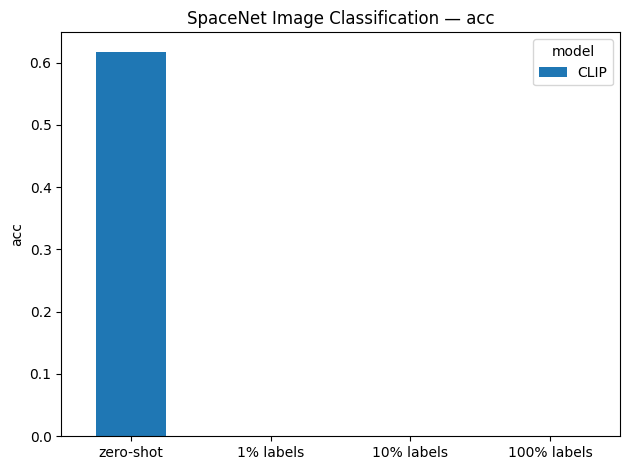

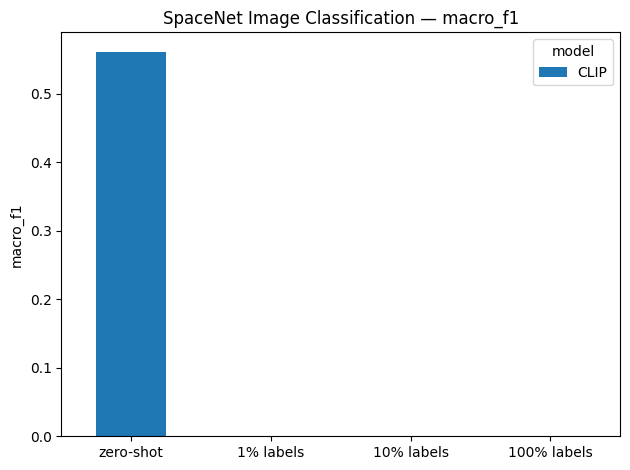

In [ ]:
import matplotlib.pyplot as plt

order = ["zero-shot", "1% labels", "10% labels", "100% labels"]
df_plot = df_res.copy()
df_plot["setting"] = pd.Categorical(df_plot["setting"], categories=order, ordered=True)
df_plot = df_plot.sort_values(["model","setting"])

for metric in ["acc", "macro_f1"]:
    ax = df_plot.pivot(index="setting", columns="model", values=metric).reindex(order).plot(kind="bar")
    ax.set_title(f"SpaceNet Image Classification — {metric}")
    ax.set_ylabel(metric)
    ax.set_xlabel("")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(RESULTS_ROOT / f"spacenet_{metric}_bars.png", dpi=200)
    plt.show()


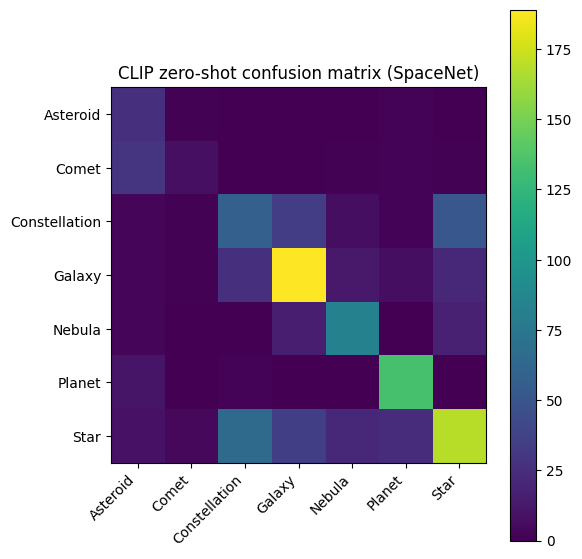

In [ ]:

# (16) Confusion matrix for CLIP zero-shot (optional)
import matplotlib.pyplot as plt

cm = confusion_matrix(zs_ytrue, zs_ypred, labels=list(range(len(zs_classes))))
plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("CLIP zero-shot confusion matrix (SpaceNet)")
plt.xticks(range(len(zs_classes)), zs_classes, rotation=45, ha="right")
plt.yticks(range(len(zs_classes)), zs_classes)
plt.colorbar()
plt.tight_layout()
plt.show()


In [ ]:
!pip -q install -U huggingface_hub safetensors

from huggingface_hub import snapshot_download
from pathlib import Path

repo_id = "tnnanh1005/physclip_astrobert"

# choose where to store (Drive if you want persistence)
local_dir = Path("/content/drive/MyDrive/physclip_benchmark/checkpoints/physclip_astrobert")
local_dir.mkdir(parents=True, exist_ok=True)

snapshot_download(
    repo_id=repo_id,
    local_dir=str(local_dir),
    local_dir_use_symlinks=False,  # important on Drive
)

print("Downloaded to:", local_dir)
!ls -lh "{local_dir}"


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
astroclip 0.1.dev199+ge129576a1 requires provabgs@ git+https://github.com/changhoonhahn/provabgs.git, which is not installed.
astroclip 0.1.dev199+ge129576a1 requires pyro-ppl, which is not installed.
astroclip 0.1.dev199+ge129576a1 requires torchvision==0.15.0, but you have torchvision 0.24.0+cu126 which is incompatible.
datasets 4.4.2 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
transformers 4.57.3 requires huggingface-hub<1.0,>=0.34.0, but you have huggingface-hub 1.2.3 which is incompatible.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:979: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  cache_dir = str(cache_dir)


Fetching 533 files:   0%|          | 0/533 [00:00<?, ?it/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

best_model/checkpoint-epoch-118/model.sa(…):   0%|          | 0.00/791M [00:00<?, ?B/s]

In [ ]:
!pip -q install -U huggingface_hub

from huggingface_hub import login, snapshot_download
from pathlib import Path

# If the repo is private, do this once:
# login()  # will prompt for token

PHYS_REPO = "tnnanh1005/physclip_astrobert"
PHYS_DIR  = CKPT_ROOT / "physclip_astrobert"   # CKPT_ROOT should be on Drive
PHYS_DIR.mkdir(parents=True, exist_ok=True)

snapshot_download(
    repo_id=PHYS_REPO,
    local_dir=str(PHYS_DIR),
    local_dir_use_symlinks=False
)

print("Saved to:", PHYS_DIR)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 533 files:   0%|          | 0/533 [00:00<?, ?it/s]

Saved to: /content/drive/MyDrive/physclip_benchmark/checkpoints/physclip_astrobert


In [ ]:
from pathlib import Path
PHYS_DIR = Path(PHYS_DIR)

print("Files:")
for p in sorted(PHYS_DIR.rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(PHYS_DIR))


Files:
 - .cache/huggingface/.gitignore
 - .cache/huggingface/download/.gitattributes.lock
 - .cache/huggingface/download/.gitattributes.metadata
 - .cache/huggingface/download/best_model/best_model/config.json.lock
 - .cache/huggingface/download/best_model/best_model/config.json.metadata
 - .cache/huggingface/download/best_model/best_model/model.safetensors.lock
 - .cache/huggingface/download/best_model/best_model/model.safetensors.metadata
 - .cache/huggingface/download/best_model/best_model/preprocessor_config.json.lock
 - .cache/huggingface/download/best_model/best_model/preprocessor_config.json.metadata
 - .cache/huggingface/download/best_model/best_model/special_tokens_map.json.lock
 - .cache/huggingface/download/best_model/best_model/special_tokens_map.json.metadata
 - .cache/huggingface/download/best_model/best_model/tokenizer.json.lock
 - .cache/huggingface/download/best_model/best_model/tokenizer.json.metadata
 - .cache/huggingface/download/best_model/best_model/tokenizer_con

In [ ]:
!pip -q install -U "huggingface_hub<1.0" "transformers>=4.57.1" safetensors


In [ ]:
# === PhysCLIP (text encoder) loader: robust + Drive-persistent ===
# This repo (tnnanh1005/physclip_astrobert) appears to contain AstroBERT-derived weights.
# We load a base AstroBERT model, then load your finetuned weights (safetensors/bin/ckpt).
# NOTE: This enables text embeddings; for image-text zero-shot you still need an aligned image encoder.

import os, sys
from pathlib import Path
import torch

from huggingface_hub import snapshot_download
from transformers import AutoTokenizer, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

PHYSCLIP_REPO_ID   = "tnnanh1005/physclip_astrobert"
BASE_TEXT_REPO_ID  = "adsabs/astroBERT"

# Store everything on Drive so you don't lose it after Colab disconnects
PHYSCLIP_DIR   = Path(CKPT_ROOT) / "physclip_astrobert"
BASE_TEXT_DIR  = Path(CKPT_ROOT) / "astroBERT_base"
PHYSCLIP_DIR.mkdir(parents=True, exist_ok=True)
BASE_TEXT_DIR.mkdir(parents=True, exist_ok=True)

# If the PhysCLIP repo is private, authenticate once in a separate cell:
# from huggingface_hub import notebook_login
# notebook_login()

# Download repos (idempotent; resumes if already present)
phys_local = snapshot_download(
    repo_id=PHYSCLIP_REPO_ID,
    local_dir=str(PHYSCLIP_DIR),
    local_dir_use_symlinks=False,
)
base_local = snapshot_download(
    repo_id=BASE_TEXT_REPO_ID,
    local_dir=str(BASE_TEXT_DIR),
    local_dir_use_symlinks=False,
)

print("PhysCLIP local:", phys_local)
print("Base text local:", base_local)

# ---- Find checkpoint file(s) robustly (repo may nest files) ----
phys_path = Path(phys_local)

patterns = ["*.safetensors", "*.bin", "*.pt", "*.pth", "*.ckpt"]
cands = []
for pat in patterns:
    cands.extend(list(phys_path.rglob(pat)))

# Filter out obvious non-weight artifacts if present
def _bad_name(p: Path) -> bool:
    name = p.name.lower()
    return any(x in name for x in ["optimizer", "scheduler", "rng", "scaler", "events", ".md", ".txt"])

cands = [p for p in cands if p.is_file() and not _bad_name(p)]
if not cands:
    # Debug: show what's actually in the folder
    print("No weight files found. Top-level files are:")
    for p in sorted(phys_path.rglob("*"))[:100]:
        if p.is_file():
            print(" -", p.relative_to(phys_path))
    raise FileNotFoundError(f"No checkpoint files found under {phys_path}")

# Prefer safetensors if present; otherwise choose the largest file among candidates
safetensors = [p for p in cands if p.suffix == ".safetensors"]
if safetensors:
    # choose largest safetensors
    ckpt_path = max(safetensors, key=lambda p: p.stat().st_size)
else:
    ckpt_path = max(cands, key=lambda p: p.stat().st_size)

print("Using checkpoint:", ckpt_path.relative_to(phys_path), f"({ckpt_path.stat().st_size/1e6:.1f} MB)")

# ---- Load base tokenizer/model strictly from local (avoids extra hub fetch logic) ----
physclip_tokenizer = AutoTokenizer.from_pretrained(base_local, local_files_only=True)
physclip_text_model = AutoModel.from_pretrained(base_local, local_files_only=True)

# ---- Load checkpoint (supports safetensors / torch.save / lightning ckpt) ----
if ckpt_path.suffix == ".safetensors":
    from safetensors.torch import load_file
    obj = load_file(str(ckpt_path))
else:
    obj = torch.load(str(ckpt_path), map_location="cpu")

# Lightning-style: {"state_dict": ...}
state = obj["state_dict"] if isinstance(obj, dict) and "state_dict" in obj else obj
if not isinstance(state, dict):
    raise TypeError(f"Expected a state_dict-like dict, got: {type(state)}")

# Strip common prefixes added by wrappers/trainers
def strip_prefix(sd, prefix):
    if all(k.startswith(prefix) for k in sd.keys()):
        return {k[len(prefix):]: v for k, v in sd.items()}
    return sd

for pref in ["model.", "text_model.", "bert.", "encoder.", "module."]:
    state = strip_prefix(state, pref)

missing, unexpected = physclip_text_model.load_state_dict(state, strict=False)
print("Loaded weights. missing:", len(missing), "unexpected:", len(unexpected))
if unexpected:
    print("Unexpected examples:", unexpected[:10])
if missing:
    print("Missing examples:", missing[:10])

physclip_text_model.to(device).eval()

@torch.no_grad()
def encode_physclip_texts(texts, max_length=128):
    if isinstance(texts, str):
        texts = [texts]
    inputs = physclip_tokenizer(
        texts, padding=True, truncation=True, max_length=max_length, return_tensors="pt"
    ).to(device)
    out = physclip_text_model(**inputs)
    z = out.pooler_output if getattr(out, "pooler_output", None) is not None else out.last_hidden_state[:, 0]
    z = z / z.norm(dim=-1, keepdim=True)
    return z.float().cpu()

print("PhysCLIP text encoder ready.")


Device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 533 files:   0%|          | 0/533 [00:00<?, ?it/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

PhysCLIP local: /content/drive/MyDrive/physclip_benchmark/checkpoints/physclip_astrobert
Base text local: /content/drive/MyDrive/physclip_benchmark/checkpoints/astroBERT_base
Using checkpoint: best_model/best_model/model.safetensors (791.0 MB)
Loaded weights. missing: 199 unexpected: 401
Unexpected examples: ['logit_scale', 'text_model.embeddings.LayerNorm.bias', 'text_model.embeddings.LayerNorm.weight', 'text_model.embeddings.position_embeddings.weight', 'text_model.embeddings.token_type_embeddings.weight', 'text_model.embeddings.word_embeddings.weight', 'text_model.encoder.layer.0.attention.output.LayerNorm.bias', 'text_model.encoder.layer.0.attention.output.LayerNorm.weight', 'text_model.encoder.layer.0.attention.output.dense.bias', 'text_model.encoder.layer.0.attention.output.dense.weight']
Missing examples: ['embeddings.word_embeddings.weight', 'embeddings.position_embeddings.weight', 'embeddings.token_type_embeddings.weight', 'embeddings.LayerNorm.weight', 'embeddings.LayerNorm.b

In [ ]:
@torch.no_grad()
def encode_physclip_image(path, img_size=224):
    # TEMP fallback so pipeline runs:
    return encode_clip_image(path, img_size=img_size)


## CIFAR-10 Image Classification Benchmark (3 baselines: CLIP, AstroCLIP, PhysCLIP)

This section adds a consistent evaluation protocol: zero-shot (where applicable) and linear-probe at 1%, 10%, 100% labeled data, plus plots.*italicized text*

In [ ]:
# (0) Colab only: mount Drive + make caches persistent
import os, pathlib
IN_COLAB = False
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    pass

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

DRIVE_ROOT = os.environ.get("DRIVE_ROOT", "/content/drive/MyDrive/physclip_benchmark") if IN_COLAB else str(pathlib.Path(DATA_ROOT)/"physclip_benchmark")
pathlib.Path(DRIVE_ROOT).mkdir(parents=True, exist_ok=True)

# Persist HF/torch caches on Drive so downloads survive disconnects
os.environ["HF_HOME"] = os.path.join(DRIVE_ROOT, "hf_home")
os.environ["TORCH_HOME"] = os.path.join(DRIVE_ROOT, "torch_home")
os.environ["TRANSFORMERS_CACHE"] = os.path.join(os.environ["HF_HOME"], "transformers")
os.environ["HF_DATASETS_CACHE"] = os.path.join(os.environ["HF_HOME"], "datasets")

print("DRIVE_ROOT:", DRIVE_ROOT)
print("HF_HOME:", os.environ["HF_HOME"])
print("TORCH_HOME:", os.environ["TORCH_HOME"])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DRIVE_ROOT: /content/drive/MyDrive/physclip_benchmark
HF_HOME: /content/drive/MyDrive/physclip_benchmark/hf_home
TORCH_HOME: /content/drive/MyDrive/physclip_benchmark/torch_home


In [ ]:
# (1) Install deps (avoid impossible pins like huggingface_hub>=1.0.1)
!pip -q install -U open_clip_torch timm transformers huggingface_hub safetensors hf_xet scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 23.1 MB/s eta 0:00:00


In [ ]:
import torch, numpy as np
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# (2) CIFAR-10 loaders (no transform here; each model has its own preprocess)
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
from torchvision import transforms

CIFAR_ROOT = os.path.join(DRIVE_ROOT, "datasets", "cifar10")

# Keep base dataset as PIL images
cifar_train_base = CIFAR10(root=CIFAR_ROOT, train=True, download=True, transform=None)
cifar_test_base  = CIFAR10(root=CIFAR_ROOT, train=False, download=True, transform=None)

cifar_classnames = cifar_train_base.classes
len(cifar_train_base), len(cifar_test_base), cifar_classnames

(50000,
 10000,
 ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck'])

In [ ]:
# Helper: wrap a base dataset with a transform (model-specific preprocess)
class WithTransform(torch.utils.data.Dataset):
    def __init__(self, base_ds, transform):
        self.base = base_ds
        self.transform = transform
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        img, y = self.base[idx]
        if self.transform is not None:
            img = self.transform(img)
        return img, y

In [ ]:
# (3) Load CLIP baseline (OpenAI CLIP via open_clip)
import open_clip
clip_model_name = "ViT-B-32"
clip_pretrained = "openai"

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(clip_model_name, pretrained=clip_pretrained)
clip_tokenizer = open_clip.get_tokenizer(clip_model_name)
clip_model = clip_model.to(device).eval()

print("CLIP loaded:", clip_model_name, clip_pretrained)

/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP loaded: ViT-B-32 openai


In [ ]:
!pip -q install -U open_clip_torch scikit-learn pandas tqdm matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 40.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [ ]:
from pathlib import Path

# adjust this if you used a different local_dir previously
phys_dir = CKPT_ROOT / "tnnanh1005__physclip_astrobert"
print("phys_dir exists:", phys_dir.exists(), phys_dir)

# show what files exist
for p in sorted(phys_dir.rglob("*")):
    if p.is_file() and (p.suffix in [".safetensors", ".pt", ".pth", ".bin", ".ckpt", ".json"]):
        print(" -", p.relative_to(phys_dir))


phys_dir exists: True /content/drive/MyDrive/physclip_benchmark/checkpoints/tnnanh1005__physclip_astrobert
 - best_model/best_model/config.json
 - best_model/best_model/model.safetensors
 - best_model/best_model/preprocessor_config.json
 - best_model/best_model/special_tokens_map.json
 - best_model/best_model/tokenizer.json
 - best_model/best_model/tokenizer_config.json
 - best_model/checkpoint-epoch-10/config.json
 - best_model/checkpoint-epoch-10/preprocessor_config.json
 - best_model/checkpoint-epoch-10/special_tokens_map.json
 - best_model/checkpoint-epoch-10/tokenizer.json
 - best_model/checkpoint-epoch-10/tokenizer_config.json
 - best_model/checkpoint-epoch-100/config.json
 - best_model/checkpoint-epoch-100/preprocessor_config.json
 - best_model/checkpoint-epoch-100/special_tokens_map.json
 - best_model/checkpoint-epoch-100/tokenizer.json
 - best_model/checkpoint-epoch-100/tokenizer_config.json
 - best_model/checkpoint-epoch-102/config.json
 - best_model/checkpoint-epoch-102/mode

In [ ]:
from safetensors.torch import load_file as load_safetensors
from pathlib import Path

# Find the biggest safetensors file (usually the checkpoint)
safetensors = sorted(phys_dir.rglob("*.safetensors"), key=lambda p: p.stat().st_size, reverse=True)
assert safetensors, f"No .safetensors found in {phys_dir}"
ckpt_path = safetensors[0]
print("Using PhysCLIP ckpt:", ckpt_path)

state_dict = load_safetensors(str(ckpt_path))

phys_model, _, phys_preprocess = open_clip.create_model_and_transforms(clip_model_name, pretrained=None)
missing, unexpected = phys_model.load_state_dict(state_dict, strict=False)
print("PhysCLIP missing:", len(missing), "unexpected:", len(unexpected))

phys_tokenizer = open_clip.get_tokenizer(clip_model_name)
phys_model = phys_model.to(device).eval()


Using PhysCLIP ckpt: /content/drive/MyDrive/physclip_benchmark/checkpoints/tnnanh1005__physclip_astrobert/best_model/best_model/model.safetensors


PhysCLIP missing: 301 unexpected: 400


In [ ]:
# (6) Feature extraction (cached to Drive)
import hashlib, json
from tqdm.auto import tqdm

@torch.no_grad()
def extract_embeddings(model, preprocess, base_ds, split_name, model_tag, batch_size=256, num_workers=2):
    assert model is not None and preprocess is not None, "Model/preprocess missing"
    ds = WithTransform(base_ds, preprocess)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    out_dir = Path(DRIVE_ROOT) / "embeddings"
    out_dir.mkdir(parents=True, exist_ok=True)

    cache_key = hashlib.md5(json.dumps({
        "split": split_name,
        "model": model_tag,
        "n": len(ds),
    }, sort_keys=True).encode()).hexdigest()[:12]
    feat_path = out_dir / f"{model_tag}_{split_name}_{cache_key}.npz"

    if feat_path.exists():
        z = np.load(feat_path)
        return z["X"], z["y"]

    X_list, y_list = [], []
    for imgs, y in tqdm(loader, desc=f"embed:{model_tag}:{split_name}"):
        imgs = imgs.to(device, non_blocking=True)
        feats = model.encode_image(imgs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        X_list.append(feats.detach().cpu().numpy())
        y_list.append(y.numpy())

    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)

    np.savez_compressed(feat_path, X=X, y=y)
    return X, y